# Laboratorio 3 - Punto 1

En este primer punto trabajamos solo con la senal generada en Python, antes de transmitir con el SDR.

## Consigna del punto 1

Realizar una grafica temporal y el histograma de cada una de las componentes de la senal. Realizar tambien una grafica en frecuencia. Describir con palabras propias lo que se observa.

La senal se genera a partir de una hipotesis binaria controlada por `ref`. Luego cada valor se repite `2**4` veces para formar un tren de pulsos.

## Configuracion SDR de referencia

Todavia no se usa el SDR en este punto, pero la consigna indica que luego se trabajara con una configuracion de este estilo:

```python
Uri = "ip:xxx.xxx.x.xx"
SamplingRate = xe6
Loopback = 0
TxLOFreq = xxxe6
TxAtten = -79
TxRfBw = xe6
tx_cyclic_buffer = True
RxLOFreq = TxLOFreq
GainControlModes = "manual"
RxHardwareGain = 70
RxRfBw = TxRfBw
RxBufferSize = len(txSignal)
```

Para el punto 1 solamente necesitamos `SamplingRate`, porque se usa para construir el eje de frecuencia.

## 1. Imports y parametros

Cargamos las librerias y definimos los parametros de la senal generada.

In [108]:
import os

os.environ["MPLCONFIGDIR"] = os.path.abspath(".matplotlib-cache")
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

plt.style.use("seaborn-v0_8-whitegrid")

seed = 20260527
rng = np.random.default_rng(seed)

nb_samples = 2**14
samples_per_symbol = 2**4
ref = 0.5

SamplingRate = 1e6

print("Semilla:", seed)
print("Cantidad de hipotesis binarias:", nb_samples)
print("Muestras por hipotesis:", samples_per_symbol)
print("ref:", ref)
print("SamplingRate:", SamplingRate)

Semilla: 20260527
Cantidad de hipotesis binarias: 16384
Muestras por hipotesis: 16
ref: 0.5
SamplingRate: 1000000.0


## 2. Generacion de la senal

Este bloque sigue la idea del codigo de la consigna:

```python
z = np.random.uniform(size=nb_samples)
x = [1 if z[i] > ref else 0 for i in range(len(z))]
txSignal = (2*np.repeat(x, 2**4)-1) + 1j*(2*np.repeat(x, 2**4)-1)
```

La diferencia es que usamos `rng`, que es la forma recomendada por NumPy para generar numeros aleatorios reproducibles.

In [109]:
z = rng.uniform(size=nb_samples)
x = np.array([1 if z_i > ref else 0 for z_i in z])

pulse_train = 2 * np.repeat(x, samples_per_symbol) - 1
txSignal = pulse_train + 1j * pulse_train

print("Primeros 20 valores binarios x:")
print(x[:20])
print("Primeras 40 muestras de txSignal:")
print(txSignal[:40])
print("Longitud de x:", len(x))
print("Longitud de txSignal:", len(txSignal))
print("Valores posibles en I:", np.unique(np.real(txSignal)))
print("Valores posibles en Q:", np.unique(np.imag(txSignal)))

Primeros 20 valores binarios x:
[0 0 1 1 1 0 1 0 1 1 0 1 1 0 1 0 1 1 0 1]
Primeras 40 muestras de txSignal:
[-1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j
 -1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j
 -1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j
 -1.-1.j -1.-1.j -1.-1.j -1.-1.j -1.-1.j  1.+1.j  1.+1.j  1.+1.j  1.+1.j
  1.+1.j  1.+1.j  1.+1.j  1.+1.j]
Longitud de x: 16384
Longitud de txSignal: 262144
Valores posibles en I: [-1.  1.]
Valores posibles en Q: [-1.  1.]


## 3. Grafica temporal de I y Q

Separamos la senal compleja en sus componentes:

- `I[n] = real(txSignal[n])`
- `Q[n] = imag(txSignal[n])`

Como I y Q fueron generadas con el mismo tren de pulsos, ambas deberian verse iguales.

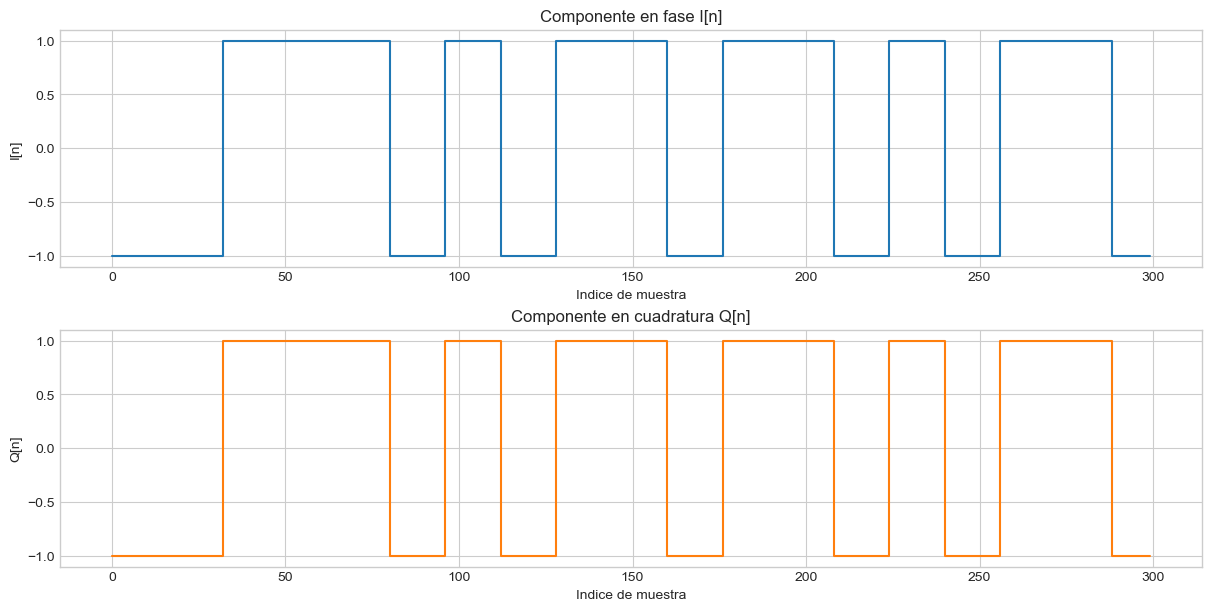

In [110]:
n_preview = 300
n = np.arange(n_preview)

tx_I = np.real(txSignal)
tx_Q = np.imag(txSignal)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)

axes[0].step(n, tx_I[:n_preview], where="post")
axes[0].set_title("Componente en fase I[n]")
axes[0].set_xlabel("Indice de muestra")
axes[0].set_ylabel("I[n]")
axes[0].grid(True)

axes[1].step(n, tx_Q[:n_preview], where="post", color="C1")
axes[1].set_title("Componente en cuadratura Q[n]")
axes[1].set_xlabel("Indice de muestra")
axes[1].set_ylabel("Q[n]")
axes[1].grid(True)

plt.show()

## 4. Histogramas de I y Q

El histograma permite ver con que frecuencia aparecen los valores de cada componente. Como `ref = 0.5`, se espera que los niveles `-1` y `+1` aparezcan aproximadamente con la misma frecuencia.

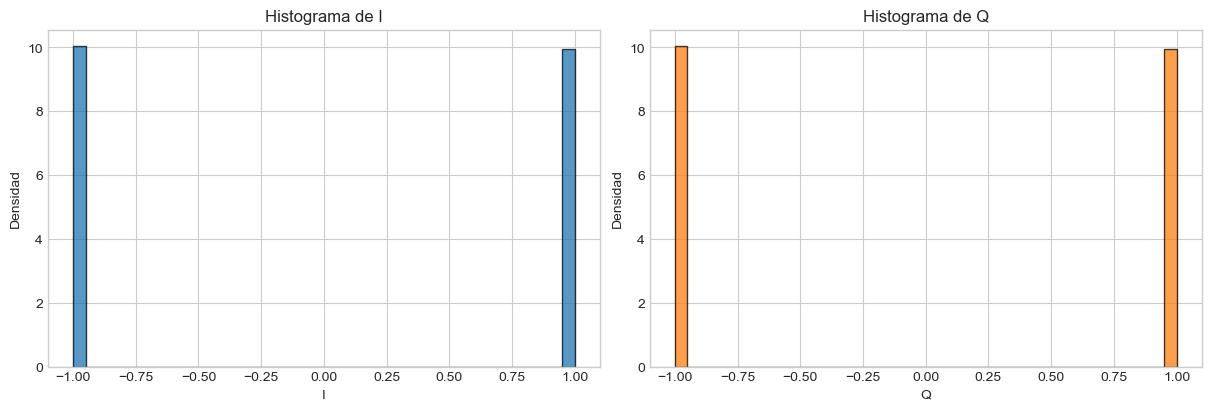

Media de I: -0.0048828125
Media de Q: -0.0048828125
Varianza de I: 0.9999761581420898
Varianza de Q: 0.9999761581420898


In [111]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].hist(tx_I, bins=40, density=True, alpha=0.75, edgecolor="black")
axes[0].set_title("Histograma de I")
axes[0].set_xlabel("I")
axes[0].set_ylabel("Densidad")
axes[0].grid(True)

axes[1].hist(tx_Q, bins=40, density=True, alpha=0.75, edgecolor="black", color="C1")
axes[1].set_title("Histograma de Q")
axes[1].set_xlabel("Q")
axes[1].set_ylabel("Densidad")
axes[1].grid(True)

plt.show()

print("Media de I:", np.mean(tx_I))
print("Media de Q:", np.mean(tx_Q))
print("Varianza de I:", np.var(tx_I))
print("Varianza de Q:", np.var(tx_Q))

## 5. Grafica en frecuencia

Estimamos la densidad espectral de potencia usando Welch. Como `txSignal` es compleja, usamos `return_onesided=False` para ver frecuencias positivas y negativas.

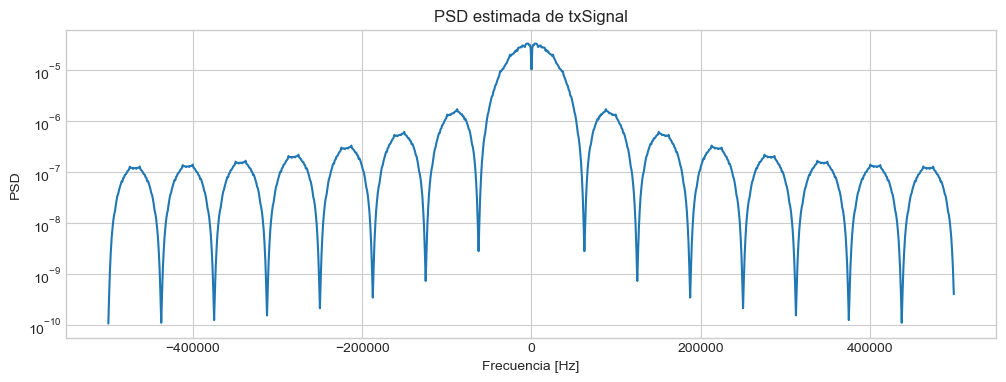

In [112]:
f, Pxx = welch(
    txSignal,
    fs=SamplingRate,
    window="hann",
    nperseg=1024,
    return_onesided=False,
    scaling="density",
)

f_shift = np.fft.fftshift(f)
Pxx_shift = np.fft.fftshift(Pxx)

plt.figure(figsize=(12, 4))
plt.semilogy(f_shift, Pxx_shift)
plt.title("PSD estimada de txSignal")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.grid(True)
plt.show()

## 6. Descripcion de lo observado

En la grafica temporal se observa que las componentes en fase `I[n]` y en cuadratura `Q[n]` toman solamente dos valores posibles: `-1` y `+1`. Esto ocurre porque la hipotesis binaria `0/1` se mapea a niveles electricos `-1/+1`. Ademas, cada simbolo se mantiene durante `2**4 = 16` muestras debido a `np.repeat(x, 2**4)`, por eso no se ve una alternancia muestra a muestra, sino tramos rectangulares cuya duracion depende de cuantos simbolos iguales aparezcan seguidos.

En los histogramas de `I` y `Q` aparecen dos concentraciones principales, una alrededor de `-1` y otra alrededor de `+1`. Como en este primer caso `ref = 0.5`, ambos valores son equiprobables y las alturas de los dos grupos deberian ser parecidas. Si no son exactamente iguales es por la cantidad finita de muestras generadas aleatoriamente.

La PSD muestra que la potencia de la senal se concentra principalmente alrededor de `0 Hz`, es decir, en banda base. Sin embargo, la senal no tiene una unica frecuencia porque no es una sinusoide pura: es un tren de pulsos rectangulares. La transformada de un pulso rectangular tiene forma tipo `sinc`, por eso aparece un lobulo principal y lobulos laterales decrecientes. Con `SamplingRate = 1e6` y `16` muestras por simbolo, la tasa de simbolos es aproximadamente `Rs = fs/16 = 62.5 ksym/s`, y los primeros minimos del espectro quedan relacionados con esa tasa de simbolos.

# Punto 2 - Transmision y recepcion con SDR

En este punto transmitimos `txSignal` usando el SDR, recibimos la senal a traves del medio inalambrico, descartamos varias capturas iniciales para limpiar transitorios y buffers viejos, normalizamos la senal recibida a potencia unitaria y analizamos sus componentes I/Q.

## 7. Configuracion del SDR

Esta celda requiere estar conectado a la VPN y usar el kernel `Python (lab3-sdr)`. Los parametros siguen la estructura de la consigna.

Importante: confirmar la IP real del SDR antes de ejecutar.

In [113]:
import adi

Uri = "ip:192.168.1.32"

Loopback = 0

# Transmitter
TxLOFreq = 2_400_000_000
TxAtten = -79
TxRfBw = int(SamplingRate)
tx_cyclic_buffer = True

# Receiver
RxLOFreq = TxLOFreq
GainControlModes = "manual"
RxHardwareGain = 70
RxRfBw = TxRfBw
RxBufferSize = len(txSignal)

sdr = adi.Pluto(Uri)

sdr.sample_rate = int(SamplingRate)
sdr.loopback = Loopback

sdr.tx_lo = int(TxLOFreq)
sdr.tx_hardwaregain_chan0 = TxAtten
sdr.tx_rf_bandwidth = int(TxRfBw)
sdr.tx_cyclic_buffer = tx_cyclic_buffer

sdr.rx_lo = int(RxLOFreq)
sdr.gain_control_mode_chan0 = GainControlModes
sdr.rx_hardwaregain_chan0 = RxHardwareGain
sdr.rx_rf_bandwidth = int(RxRfBw)
sdr.rx_buffer_size = int(RxBufferSize)

print("SDR conectado en:", Uri)
print("SamplingRate:", sdr.sample_rate)
print("TxLOFreq:", sdr.tx_lo)
print("RxLOFreq:", sdr.rx_lo)
print("TxAtten:", sdr.tx_hardwaregain_chan0)
print("RxHardwareGain:", sdr.rx_hardwaregain_chan0)
print("RxBufferSize:", sdr.rx_buffer_size)

SDR conectado en: ip:192.168.1.32
SamplingRate: 999999
TxLOFreq: 2400000000
RxLOFreq: 2400000000
TxAtten: -79
RxHardwareGain: 70
RxBufferSize: 262144


## 8. Transmision, limpieza de buffer y recepcion

La consigna recomienda transmitir en modo continuo y realizar varias recepciones antes de guardar la captura final. Esto evita analizar muestras tomadas durante un transitorio inicial o datos que hayan quedado en el buffer del receptor.

In [114]:
# ---- Transmitter
sdr.tx_destroy_buffer()
sdr.tx(txSignal * (2**14))

# ---- Clear Rx buffer
for i in range(10):
    raw_data = sdr.rx()

# ---- Receiver
rxSignal = sdr.rx()

print("Longitud de txSignal:", len(txSignal))
print("Longitud de rxSignal:", len(rxSignal))
print("Primeras 10 muestras recibidas:")
print(rxSignal[:10])

Longitud de txSignal: 262144
Longitud de rxSignal: 262144
Primeras 10 muestras recibidas:
[47. +0.j 57. +9.j 24.+23.j 10. +4.j 31.-10.j 27. +4.j 20.+19.j 28.-22.j
 17.-32.j 25.-12.j]


## 9. Normalizacion de potencia

Normalizamos la senal recibida para que su potencia promedio sea igual a 1. Esto permite comparar graficas aunque la ganancia del receptor o la atenuacion del transmisor cambien la escala de amplitud.

In [115]:
rxPower = np.mean(np.abs(rxSignal)**2)
rxSignalNorm = rxSignal / np.sqrt(rxPower)

print("Potencia recibida antes de normalizar:", rxPower)
print("Potencia recibida despues de normalizar:", np.mean(np.abs(rxSignalNorm)**2))

rx_I = np.real(rxSignalNorm)
rx_Q = np.imag(rxSignalNorm)

Potencia recibida antes de normalizar: 1058.3605461120605
Potencia recibida despues de normalizar: 1.0000000000000002


## 10. Grafica temporal de la senal recibida normalizada

A diferencia del punto 1, ahora la senal paso por el SDR y el medio inalambrico. Por eso no esperamos ver pulsos perfectamente cuadrados.

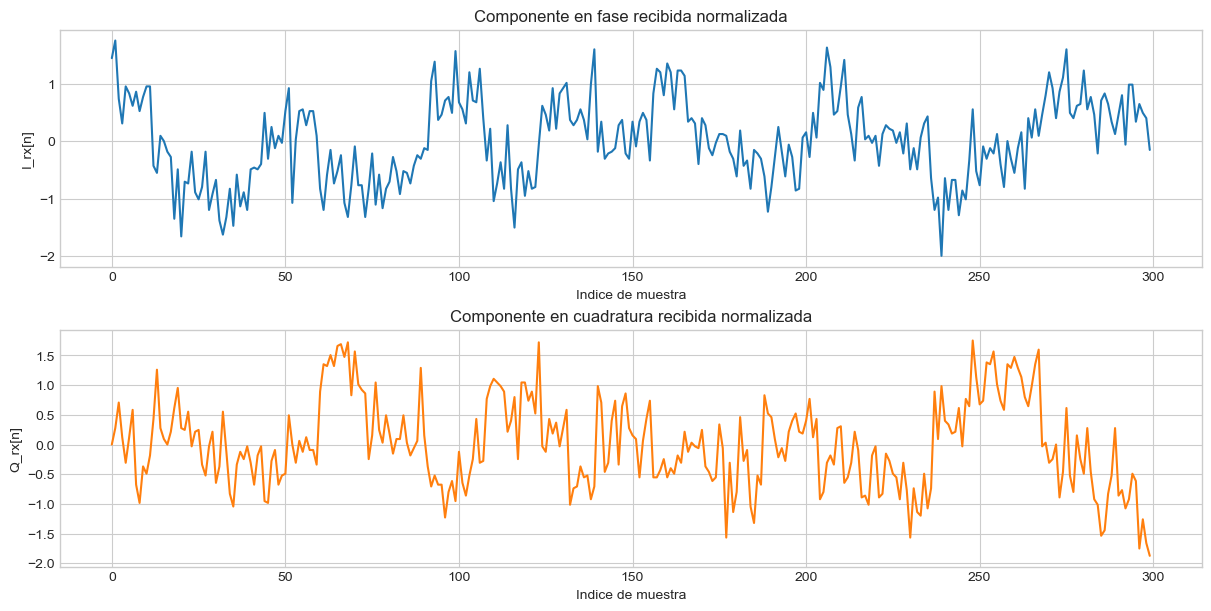

In [116]:
n_preview_rx = 300
n_rx = np.arange(n_preview_rx)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)

axes[0].plot(n_rx, rx_I[:n_preview_rx])
axes[0].set_title("Componente en fase recibida normalizada")
axes[0].set_xlabel("Indice de muestra")
axes[0].set_ylabel("I_rx[n]")
axes[0].grid(True)

axes[1].plot(n_rx, rx_Q[:n_preview_rx], color="C1")
axes[1].set_title("Componente en cuadratura recibida normalizada")
axes[1].set_xlabel("Indice de muestra")
axes[1].set_ylabel("Q_rx[n]")
axes[1].grid(True)

plt.show()

## 11. Histogramas de la senal recibida normalizada

Los histogramas permiten ver como se distribuyen las muestras recibidas en I y Q despues de pasar por el SDR. Si el canal y la recepcion fueran ideales, los valores estarian muy concentrados alrededor de dos niveles. En la practica pueden aparecer dispersion, desplazamientos y rotaciones.

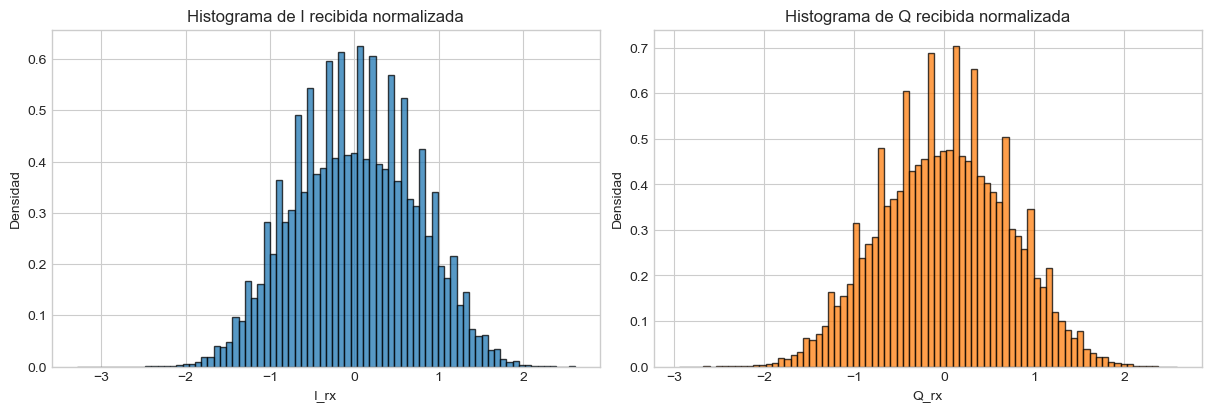

Media de I_rx: 0.0032985906826688187
Media de Q_rx: 0.006058731668746147
Varianza de I_rx: 0.5077790961094004
Varianza de Q_rx: 0.492173314960674


In [117]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].hist(rx_I, bins=80, density=True, alpha=0.75, edgecolor="black")
axes[0].set_title("Histograma de I recibida normalizada")
axes[0].set_xlabel("I_rx")
axes[0].set_ylabel("Densidad")
axes[0].grid(True)

axes[1].hist(rx_Q, bins=80, density=True, alpha=0.75, edgecolor="black", color="C1")
axes[1].set_title("Histograma de Q recibida normalizada")
axes[1].set_xlabel("Q_rx")
axes[1].set_ylabel("Densidad")
axes[1].grid(True)

plt.show()

print("Media de I_rx:", np.mean(rx_I))
print("Media de Q_rx:", np.mean(rx_Q))
print("Varianza de I_rx:", np.var(rx_I))
print("Varianza de Q_rx:", np.var(rx_Q))

## 12. Descripcion de lo observado en el punto 2

Luego de transmitir y recibir con el SDR, la senal deja de verse como un tren rectangular ideal. Esto es esperable porque ahora la senal atraveso el medio inalambrico y tambien los bloques reales del hardware: conversores, filtros analogicos, osciladores, ganancia de recepcion y posibles desajustes de fase o sincronismo. Por eso en tiempo se observan muestras mas dispersas y transiciones menos limpias que en la senal generada digitalmente.

La normalizacion no significa tomar solamente el valor absoluto. En este punto se normaliza dividiendo por la raiz de la potencia promedio, calculada como `sqrt(mean(abs(rxSignal)**2))`. De esa forma la potencia media queda igual a uno, pero se conserva la informacion compleja `I/Q`. La normalizacion ajusta la escala de amplitud para comparar graficas, pero no elimina el ruido ni corrige las distorsiones del canal.

En los histogramas, los niveles que antes estaban concentrados en `-1` y `+1` aparecen ensanchados o mezclados. Esto se relaciona con el modelo de canal con ruido aditivo: cada muestra recibida puede pensarse como la muestra transmitida mas una perturbacion. Si la relacion senal-ruido es baja, el histograma puede parecerse mas a una campana alrededor de cero; si la recepcion es mejor, empiezan a distinguirse dos regiones asociadas a los dos niveles transmitidos.

# Punto 3 - Filtrado con pulso rectangular

La consigna pide filtrar la senal recibida con un pulso rectangular de `2**4` muestras distintas de cero. Como `2**4 = 16`, usamos un filtro con 16 unos.

Este bloque se relaciona con la idea de integrar o acumular la senal durante la duracion de un simbolo. En el simulador del Parcial 2, esto se parecia al correlador o al matched filter para un pulso rectangular.

## 13. Construccion del pulso rectangular y filtrado

El pulso rectangular discreto es un array de 16 muestras iguales a 1. Al filtrar con este pulso, cada salida combina varias muestras vecinas de la senal recibida.

In [118]:
rect_pulse_len = 2**4
rect_pulse = np.ones(rect_pulse_len)

rxSignalFiltered = np.convolve(rxSignalNorm, rect_pulse, mode="same")

rxFiltered_I = np.real(rxSignalFiltered)
rxFiltered_Q = np.imag(rxSignalFiltered)

print("Longitud del pulso rectangular:", len(rect_pulse))
print("Pulso rectangular:", rect_pulse)
print("Longitud de rxSignalNorm:", len(rxSignalNorm))
print("Longitud de rxSignalFiltered:", len(rxSignalFiltered))

Longitud del pulso rectangular: 16
Pulso rectangular: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Longitud de rxSignalNorm: 262144
Longitud de rxSignalFiltered: 262144


## 14. Grafica temporal de la senal filtrada

Se grafican las componentes I y Q luego del filtrado rectangular. La amplitud puede cambiar porque el filtro suma energia durante 16 muestras.

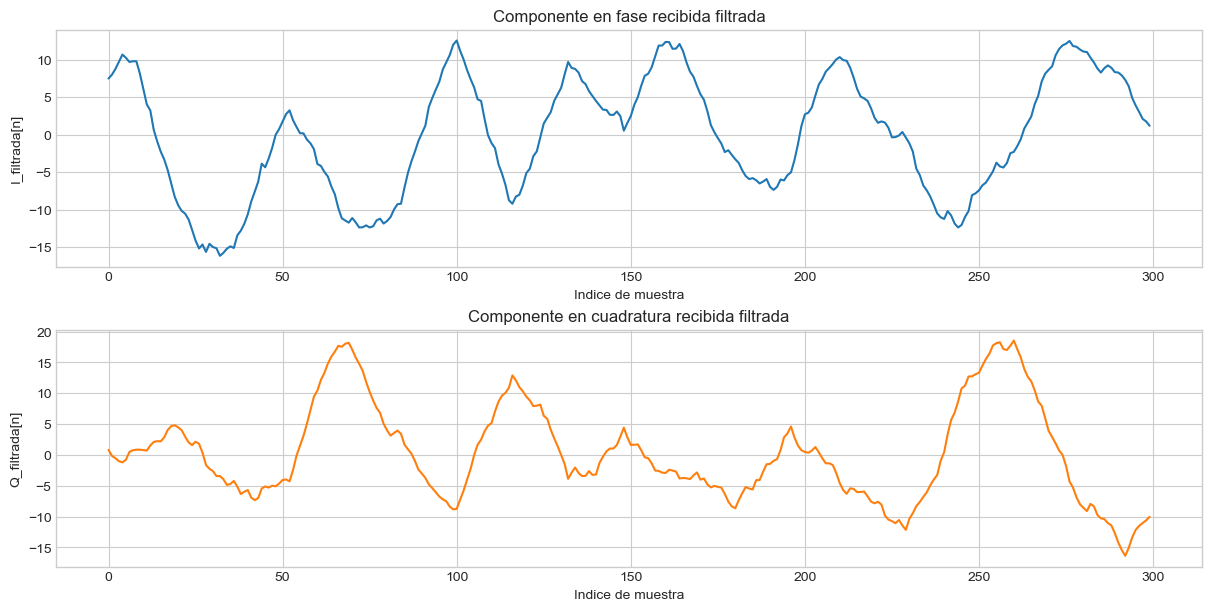

In [119]:
n_preview_filtered = 300
n_filtered = np.arange(n_preview_filtered)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)

axes[0].plot(n_filtered, rxFiltered_I[:n_preview_filtered])
axes[0].set_title("Componente en fase recibida filtrada")
axes[0].set_xlabel("Indice de muestra")
axes[0].set_ylabel("I_filtrada[n]")
axes[0].grid(True)

axes[1].plot(n_filtered, rxFiltered_Q[:n_preview_filtered], color="C1")
axes[1].set_title("Componente en cuadratura recibida filtrada")
axes[1].set_xlabel("Indice de muestra")
axes[1].set_ylabel("Q_filtrada[n]")
axes[1].grid(True)

plt.show()

## 15. Histogramas de la senal filtrada

El histograma luego del filtrado permite observar si la acumulacion sobre 16 muestras ayuda a separar mejor los niveles recibidos o si la dispersion del canal sigue mezclandolos.

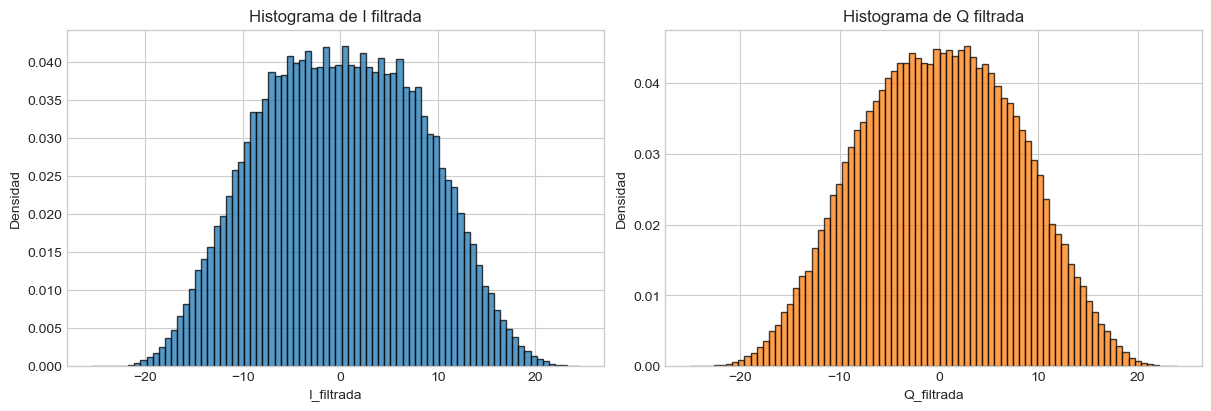

Media de I filtrada: 0.05255278419389681
Media de Q filtrada: 0.0969405275074027
Varianza de I filtrada: 66.49859085994102
Varianza de Q filtrada: 60.826646716873604


In [120]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].hist(rxFiltered_I, bins=80, density=True, alpha=0.75, edgecolor="black")
axes[0].set_title("Histograma de I filtrada")
axes[0].set_xlabel("I_filtrada")
axes[0].set_ylabel("Densidad")
axes[0].grid(True)

axes[1].hist(rxFiltered_Q, bins=80, density=True, alpha=0.75, edgecolor="black", color="C1")
axes[1].set_title("Histograma de Q filtrada")
axes[1].set_xlabel("Q_filtrada")
axes[1].set_ylabel("Densidad")
axes[1].grid(True)

plt.show()

print("Media de I filtrada:", np.mean(rxFiltered_I))
print("Media de Q filtrada:", np.mean(rxFiltered_Q))
print("Varianza de I filtrada:", np.var(rxFiltered_I))
print("Varianza de Q filtrada:", np.var(rxFiltered_Q))

## 16. Descripcion de lo observado en el punto 3

En este punto se filtra la senal recibida con un pulso rectangular de `16` muestras porque esa fue justamente la forma de pulso usada para transmitir cada simbolo. En terminos teoricos, esto se relaciona con el filtro adaptado o `matched filter`: el receptor usa un filtro con la misma forma del pulso transmitido para acumular energia durante la duracion de un simbolo.

Como el filtro rectangular esta formado por unos, la salida es similar a una suma movil de 16 muestras consecutivas. Por eso la amplitud de la senal filtrada puede ocupar un rango mayor que la senal normalizada original. No significa que aparezcan nuevos simbolos; significa que el receptor esta integrando energia de varias muestras para obtener una observacion mas robusta antes de decidir que simbolo fue transmitido.

En la grafica temporal pueden aparecer formas triangulares o rampas durante las transiciones. Esto ocurre porque la ventana de 16 muestras va entrando y saliendo de zonas donde el simbolo cambia de nivel: al principio suma mas muestras de un simbolo anterior y luego mas muestras del simbolo nuevo. En los histogramas todavia se observa dispersion por ruido y por efectos del canal, pero la idea del filtrado es mejorar la separacion estadistica de los niveles utiles antes de una posible etapa de decision.

# Punto 4 - Aumento de potencia transmitida

La consigna pide repetir los pasos anteriores aumentando la potencia de la senal transmitida. Para eso se cambia `TxAtten` de `-79` a `-70`.

En este SDR, un valor menos negativo implica menor atenuacion en transmision. Por lo tanto, `TxAtten = -70` transmite con mas potencia que `TxAtten = -79`.

## 17. Retransmision con `TxAtten = -70`

Se vuelve a transmitir la misma senal `txSignal`, pero con mayor potencia. Igual que antes, se descartan varias recepciones iniciales para evitar transitorios y limpiar el buffer del receptor.

In [121]:
TxAtten_high_power = -70

sdr.tx_destroy_buffer()
sdr.tx_hardwaregain_chan0 = TxAtten_high_power
sdr.tx(txSignal * (2**14))

for i in range(10):
    raw_data_high_power = sdr.rx()

rxSignalHighPower = sdr.rx()

print("TxAtten anterior:", TxAtten)
print("TxAtten nuevo:", sdr.tx_hardwaregain_chan0)
print("Longitud de rxSignalHighPower:", len(rxSignalHighPower))
print("Primeras 10 muestras recibidas con mayor potencia:")
print(rxSignalHighPower[:10])

TxAtten anterior: -79
TxAtten nuevo: -70
Longitud de rxSignalHighPower: 262144
Primeras 10 muestras recibidas con mayor potencia:
[-41.+40.j -56.+24.j -22.+40.j -55.+66.j -42.+36.j -36.+29.j -17.+43.j
 -35.+10.j -49.+29.j -35.+28.j]


## 18. Normalizacion y grafica temporal con mayor potencia

Se normaliza la nueva recepcion a potencia unitaria para comparar la forma y la distribucion de las muestras sin que la escala absoluta tape el analisis.

Potencia antes de normalizar con TxAtten = -70: 4386.720611572266
Potencia despues de normalizar con TxAtten = -70: 1.0000000000000002


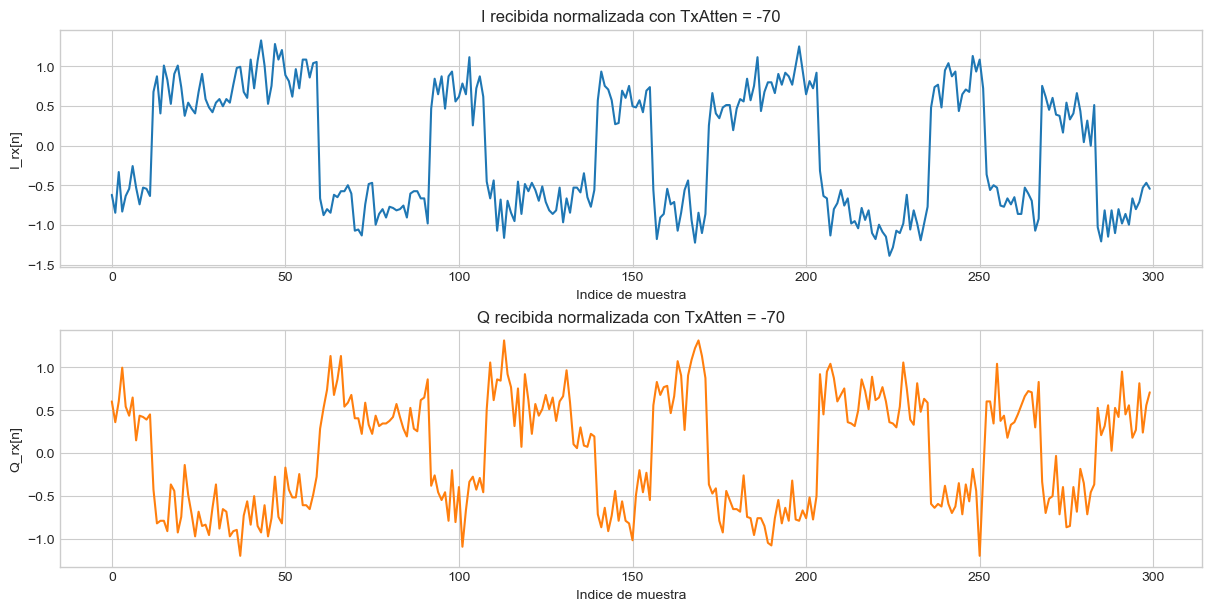

In [122]:
rxPowerHigh = np.mean(np.abs(rxSignalHighPower)**2)
rxSignalHighPowerNorm = rxSignalHighPower / np.sqrt(rxPowerHigh)

rxHigh_I = np.real(rxSignalHighPowerNorm)
rxHigh_Q = np.imag(rxSignalHighPowerNorm)

print("Potencia antes de normalizar con TxAtten = -70:", rxPowerHigh)
print("Potencia despues de normalizar con TxAtten = -70:", np.mean(np.abs(rxSignalHighPowerNorm)**2))

n_preview_high = 300
n_high = np.arange(n_preview_high)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)

axes[0].plot(n_high, rxHigh_I[:n_preview_high])
axes[0].set_title("I recibida normalizada con TxAtten = -70")
axes[0].set_xlabel("Indice de muestra")
axes[0].set_ylabel("I_rx[n]")
axes[0].grid(True)

axes[1].plot(n_high, rxHigh_Q[:n_preview_high], color="C1")
axes[1].set_title("Q recibida normalizada con TxAtten = -70")
axes[1].set_xlabel("Indice de muestra")
axes[1].set_ylabel("Q_rx[n]")
axes[1].grid(True)

plt.show()

## 19. Histogramas con mayor potencia y comparacion

Primero se grafican los histogramas de la nueva recepcion normalizada. Luego se superponen con los histogramas obtenidos anteriormente con `TxAtten = -79` para comparar la dispersion.

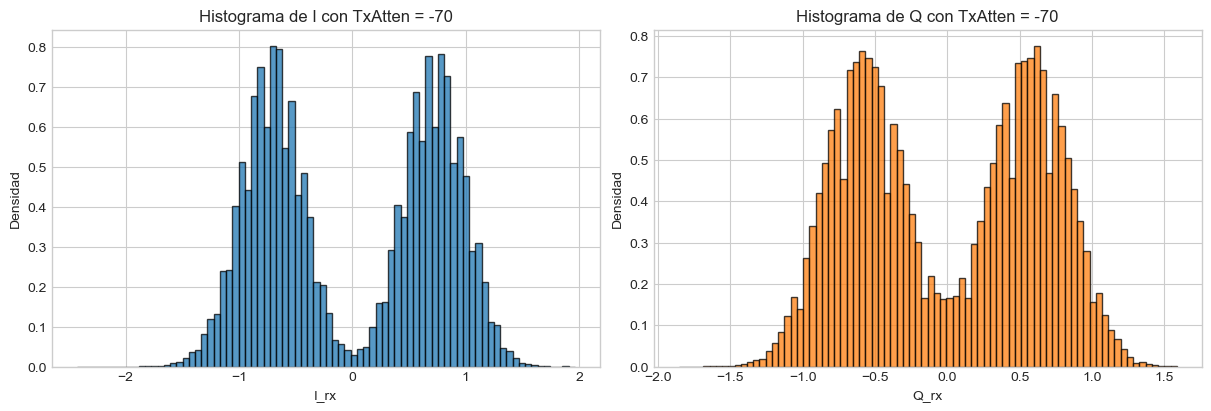

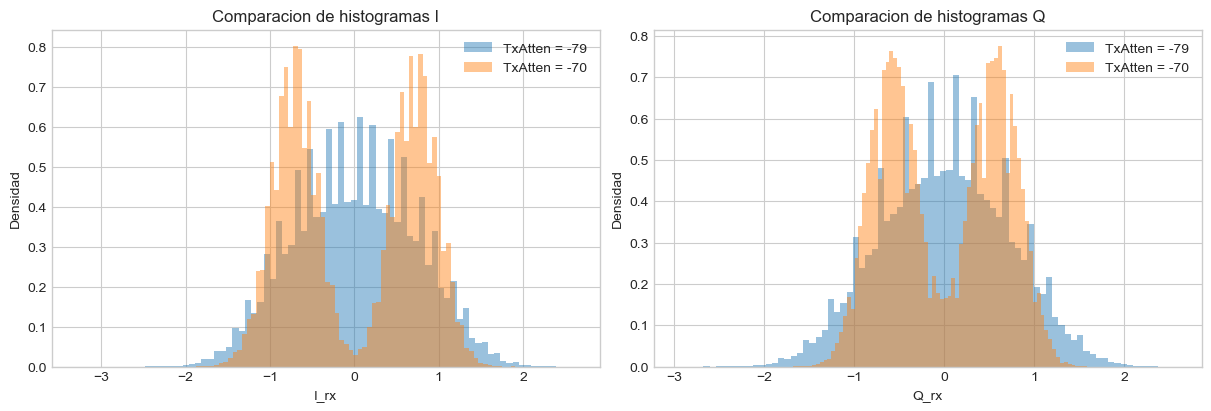

Media I con TxAtten = -70: -2.943140469918032e-05
Media Q con TxAtten = -70: -0.0016570859972604665
Varianza I con TxAtten = -70: 0.5943401098184351
Varianza Q con TxAtten = -70: 0.4056571433813553


In [123]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].hist(rxHigh_I, bins=80, density=True, alpha=0.75, edgecolor="black")
axes[0].set_title("Histograma de I con TxAtten = -70")
axes[0].set_xlabel("I_rx")
axes[0].set_ylabel("Densidad")
axes[0].grid(True)

axes[1].hist(rxHigh_Q, bins=80, density=True, alpha=0.75, edgecolor="black", color="C1")
axes[1].set_title("Histograma de Q con TxAtten = -70")
axes[1].set_xlabel("Q_rx")
axes[1].set_ylabel("Densidad")
axes[1].grid(True)

plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].hist(rx_I, bins=80, density=True, alpha=0.45, label="TxAtten = -79")
axes[0].hist(rxHigh_I, bins=80, density=True, alpha=0.45, label="TxAtten = -70")
axes[0].set_title("Comparacion de histogramas I")
axes[0].set_xlabel("I_rx")
axes[0].set_ylabel("Densidad")
axes[0].legend()
axes[0].grid(True)

axes[1].hist(rx_Q, bins=80, density=True, alpha=0.45, label="TxAtten = -79")
axes[1].hist(rxHigh_Q, bins=80, density=True, alpha=0.45, label="TxAtten = -70")
axes[1].set_title("Comparacion de histogramas Q")
axes[1].set_xlabel("Q_rx")
axes[1].set_ylabel("Densidad")
axes[1].legend()
axes[1].grid(True)

plt.show()

print("Media I con TxAtten = -70:", np.mean(rxHigh_I))
print("Media Q con TxAtten = -70:", np.mean(rxHigh_Q))
print("Varianza I con TxAtten = -70:", np.var(rxHigh_I))
print("Varianza Q con TxAtten = -70:", np.var(rxHigh_Q))

## 20. PSD con mayor potencia y comparacion

Como el punto 4 pide repetir los pasos anteriores, tambien estimamos la PSD de la senal recibida con `TxAtten = -70` y la comparamos con la PSD del caso anterior.

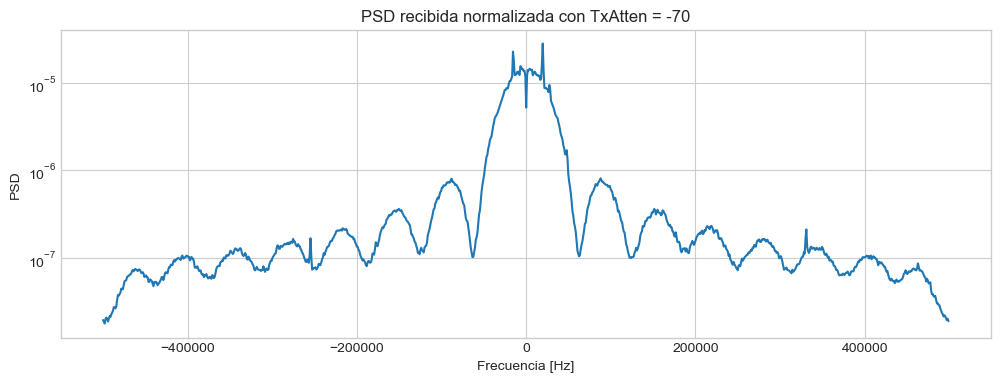

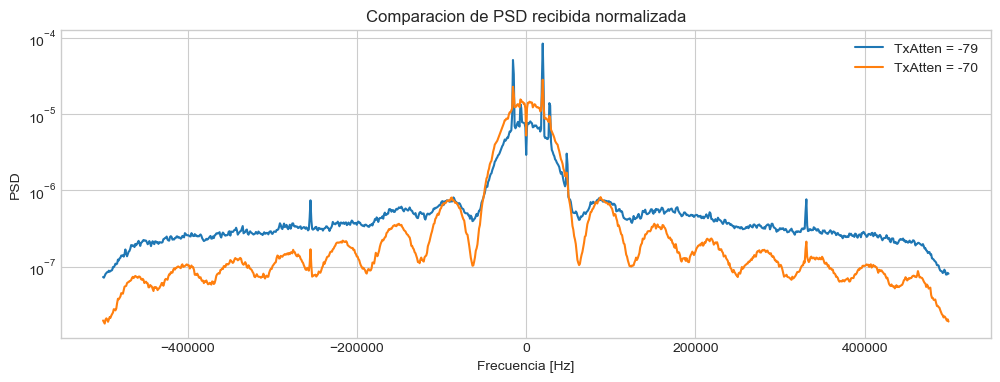

In [124]:
f_rx, Pxx_rx = welch(
    rxSignalNorm,
    fs=SamplingRate,
    window="hann",
    nperseg=1024,
    return_onesided=False,
    scaling="density",
)

f_high, Pxx_high = welch(
    rxSignalHighPowerNorm,
    fs=SamplingRate,
    window="hann",
    nperseg=1024,
    return_onesided=False,
    scaling="density",
)

f_rx_shift = np.fft.fftshift(f_rx)
Pxx_rx_shift = np.fft.fftshift(Pxx_rx)
f_high_shift = np.fft.fftshift(f_high)
Pxx_high_shift = np.fft.fftshift(Pxx_high)

plt.figure(figsize=(12, 4))
plt.semilogy(f_high_shift, Pxx_high_shift)
plt.title("PSD recibida normalizada con TxAtten = -70")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.semilogy(f_rx_shift, Pxx_rx_shift, label="TxAtten = -79")
plt.semilogy(f_high_shift, Pxx_high_shift, label="TxAtten = -70")
plt.title("Comparacion de PSD recibida normalizada")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.legend()
plt.grid(True)
plt.show()

## 21. Filtrado rectangular con mayor potencia

Para repetir tambien el filtrado del punto 3, aplicamos el mismo pulso rectangular de 16 muestras sobre la senal recibida con `TxAtten = -70`.

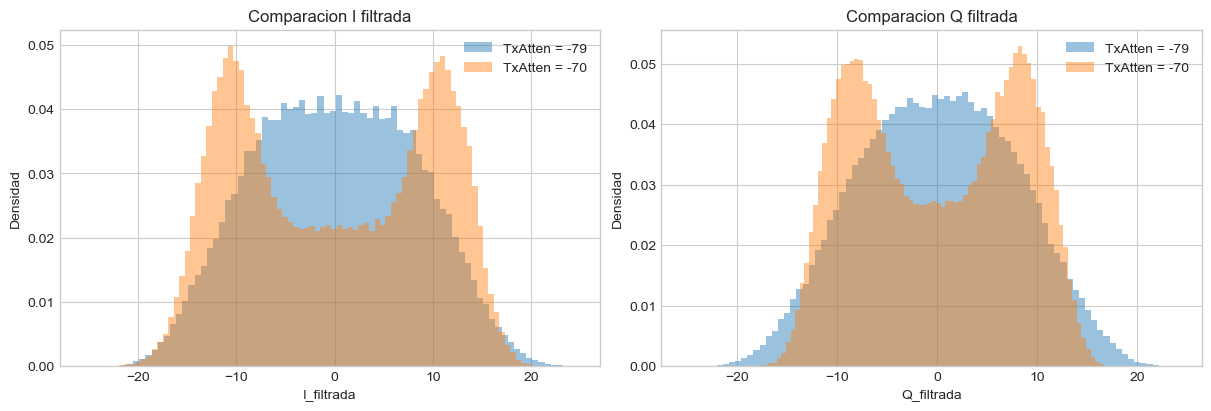

In [125]:
rxSignalHighPowerFiltered = np.convolve(rxSignalHighPowerNorm, rect_pulse, mode="same")

rxHighFiltered_I = np.real(rxSignalHighPowerFiltered)
rxHighFiltered_Q = np.imag(rxSignalHighPowerFiltered)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].hist(rxFiltered_I, bins=80, density=True, alpha=0.45, label="TxAtten = -79")
axes[0].hist(rxHighFiltered_I, bins=80, density=True, alpha=0.45, label="TxAtten = -70")
axes[0].set_title("Comparacion I filtrada")
axes[0].set_xlabel("I_filtrada")
axes[0].set_ylabel("Densidad")
axes[0].legend()
axes[0].grid(True)

axes[1].hist(rxFiltered_Q, bins=80, density=True, alpha=0.45, label="TxAtten = -79")
axes[1].hist(rxHighFiltered_Q, bins=80, density=True, alpha=0.45, label="TxAtten = -70")
axes[1].set_title("Comparacion Q filtrada")
axes[1].set_xlabel("Q_filtrada")
axes[1].set_ylabel("Densidad")
axes[1].legend()
axes[1].grid(True)

plt.show()

## 22. PSD de la senal filtrada con mayor potencia

Tambien comparamos en frecuencia las senales filtradas de ambos casos.

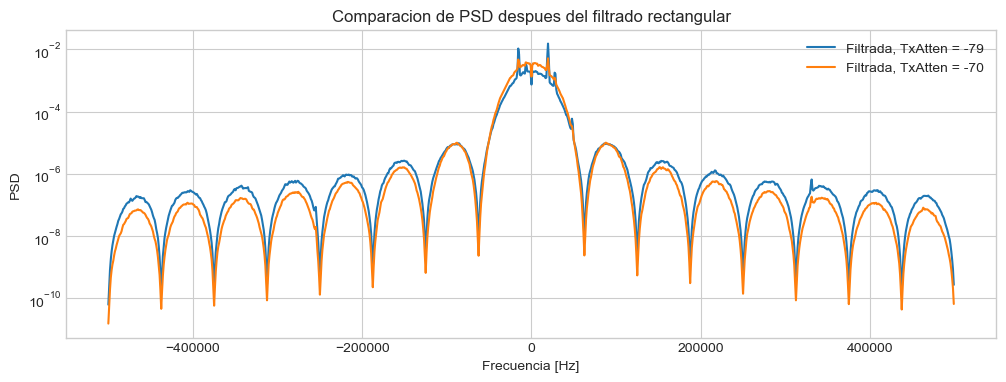

In [126]:
f_filt, Pxx_filt = welch(
    rxSignalFiltered,
    fs=SamplingRate,
    window="hann",
    nperseg=1024,
    return_onesided=False,
    scaling="density",
)

f_high_filt, Pxx_high_filt = welch(
    rxSignalHighPowerFiltered,
    fs=SamplingRate,
    window="hann",
    nperseg=1024,
    return_onesided=False,
    scaling="density",
)

plt.figure(figsize=(12, 4))
plt.semilogy(np.fft.fftshift(f_filt), np.fft.fftshift(Pxx_filt), label="Filtrada, TxAtten = -79")
plt.semilogy(np.fft.fftshift(f_high_filt), np.fft.fftshift(Pxx_high_filt), label="Filtrada, TxAtten = -70")
plt.title("Comparacion de PSD despues del filtrado rectangular")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.legend()
plt.grid(True)
plt.show()

## 23. Descripcion de lo observado en el punto 4

Al cambiar `TxAtten` de `-79` a `-70` se reduce la atenuacion aplicada por el transmisor, por lo tanto el SDR emite con mayor potencia. Aunque despues normalicemos la senal recibida a potencia unitaria, el aumento de potencia ocurre antes de la normalizacion y puede mejorar la relacion senal-ruido en la captura real.

La diferencia mas importante se observa en los histogramas. En el caso de menor potencia, la distribucion podia parecerse mas a una campana alrededor de cero, lo que indica que el ruido y los efectos del canal dominaban la observacion. Al aumentar la potencia transmitida, aparecen con mayor claridad dos campanas o dos regiones alrededor de niveles negativos y positivos. Esto significa que los simbolos transmitidos empiezan a distinguirse mejor respecto del ruido.

En frecuencia, la PSD permite comparar la forma espectral de la senal recibida antes y despues del aumento de potencia. Como la senal sigue estando construida con pulsos rectangulares, se mantiene una estructura con mayor concentracion de potencia cerca de banda base y lobulos laterales. Si al aumentar la potencia aparecieran deformaciones excesivas, eso podria indicar saturacion o comportamiento no lineal del hardware; si no aparecen, el cambio se interpreta principalmente como una mejora de la recepcion.

# Punto 5 - Repeticion con `ref = 0.3`

Ahora repetimos el experimento cambiando la probabilidad de ocurrencia de las hipotesis binarias. Con `ref = 0.3`, la regla `x = 1 if z > ref else 0` hace que el valor `1` sea mas probable que el valor `0`.

En teoria, si `z` es uniforme entre 0 y 1:

- `P(x = 0) = P(z <= 0.3) = 0.3`
- `P(x = 1) = P(z > 0.3) = 0.7`

Entonces, despues del mapeo `0 -> -1` y `1 -> +1`, se espera que haya mas muestras positivas que negativas.

## 24. Generacion de la senal con `ref = 0.3`

Se genera una nueva senal `txSignal_ref03` usando la misma estructura del punto 1, pero con `ref = 0.3`.

In [127]:
ref_03 = 0.3

z_ref03 = rng.uniform(size=nb_samples)
x_ref03 = np.array([1 if z_i > ref_03 else 0 for z_i in z_ref03])

pulse_train_ref03 = 2 * np.repeat(x_ref03, samples_per_symbol) - 1
txSignal_ref03 = pulse_train_ref03 + 1j * pulse_train_ref03

print("ref usado:", ref_03)
print("Fraccion de ceros:", np.mean(x_ref03 == 0))
print("Fraccion de unos:", np.mean(x_ref03 == 1))
print("Longitud de txSignal_ref03:", len(txSignal_ref03))
print("Valores posibles en I:", np.unique(np.real(txSignal_ref03)))
print("Valores posibles en Q:", np.unique(np.imag(txSignal_ref03)))

ref usado: 0.3
Fraccion de ceros: 0.30096435546875
Fraccion de unos: 0.69903564453125
Longitud de txSignal_ref03: 262144
Valores posibles en I: [-1.  1.]
Valores posibles en Q: [-1.  1.]


## 25. Analisis local de la senal con `ref = 0.3`

Antes de transmitir, miramos tiempo, histogramas y PSD de la senal generada. El cambio mas importante deberia aparecer en los histogramas: el nivel `+1` deberia tener mayor peso que el nivel `-1`.

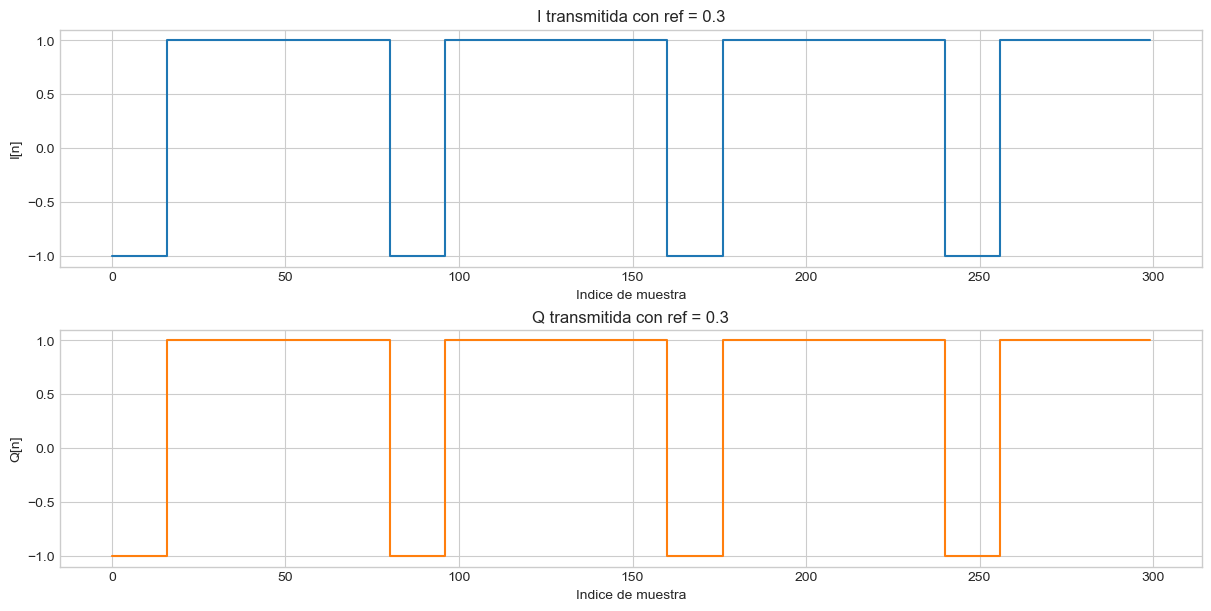

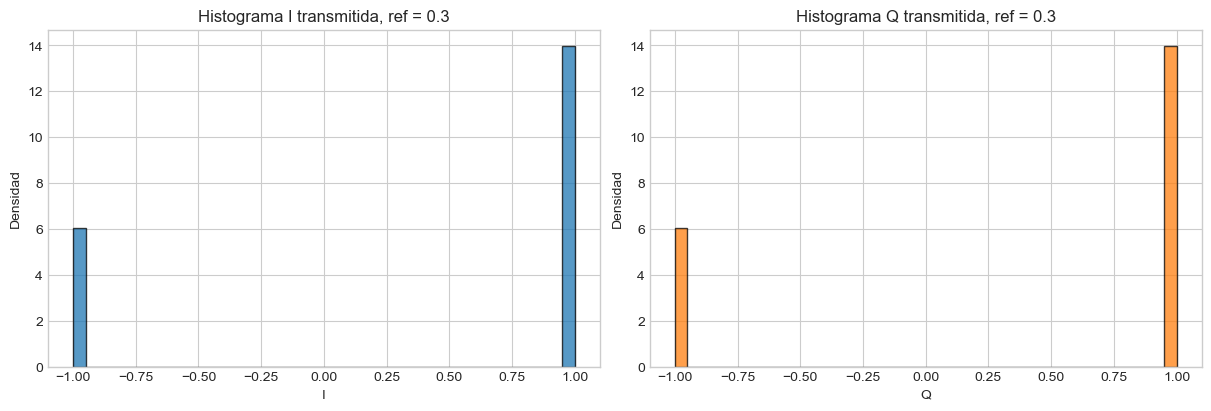

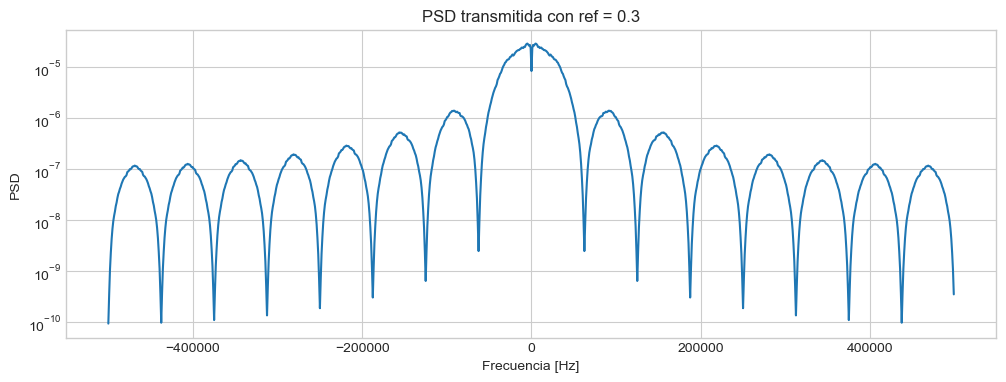

In [128]:
tx_I_ref03 = np.real(txSignal_ref03)
tx_Q_ref03 = np.imag(txSignal_ref03)

n_preview_ref03 = 300
n_ref03 = np.arange(n_preview_ref03)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)
axes[0].step(n_ref03, tx_I_ref03[:n_preview_ref03], where="post")
axes[0].set_title("I transmitida con ref = 0.3")
axes[0].set_xlabel("Indice de muestra")
axes[0].set_ylabel("I[n]")
axes[0].grid(True)

axes[1].step(n_ref03, tx_Q_ref03[:n_preview_ref03], where="post", color="C1")
axes[1].set_title("Q transmitida con ref = 0.3")
axes[1].set_xlabel("Indice de muestra")
axes[1].set_ylabel("Q[n]")
axes[1].grid(True)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].hist(tx_I_ref03, bins=40, density=True, alpha=0.75, edgecolor="black")
axes[0].set_title("Histograma I transmitida, ref = 0.3")
axes[0].set_xlabel("I")
axes[0].set_ylabel("Densidad")
axes[0].grid(True)

axes[1].hist(tx_Q_ref03, bins=40, density=True, alpha=0.75, edgecolor="black", color="C1")
axes[1].set_title("Histograma Q transmitida, ref = 0.3")
axes[1].set_xlabel("Q")
axes[1].set_ylabel("Densidad")
axes[1].grid(True)
plt.show()

f_ref03, Pxx_ref03 = welch(
    txSignal_ref03,
    fs=SamplingRate,
    window="hann",
    nperseg=1024,
    return_onesided=False,
    scaling="density",
)

plt.figure(figsize=(12, 4))
plt.semilogy(np.fft.fftshift(f_ref03), np.fft.fftshift(Pxx_ref03))
plt.title("PSD transmitida con ref = 0.3")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.grid(True)
plt.show()

## 26. Transmision y recepcion con `ref = 0.3`

Se transmite la nueva senal usando la misma configuracion de mayor potencia del punto 4 (`TxAtten = -70`). Luego se limpian buffers y se toma la captura final.

In [129]:
sdr.tx_destroy_buffer()
sdr.tx_hardwaregain_chan0 = TxAtten_high_power
sdr.rx_buffer_size = len(txSignal_ref03)
sdr.tx(txSignal_ref03 * (2**14))

for i in range(10):
    raw_data_ref03 = sdr.rx()

rxSignal_ref03 = sdr.rx()

print("TxAtten usado:", sdr.tx_hardwaregain_chan0)
print("Longitud de rxSignal_ref03:", len(rxSignal_ref03))
print("Primeras 10 muestras recibidas:")
print(rxSignal_ref03[:10])

TxAtten usado: -70
Longitud de rxSignal_ref03: 262144
Primeras 10 muestras recibidas:
[17.-24.j 10.-32.j 37.-55.j 37.-50.j 14.-50.j 15.-46.j 20.-40.j 26.-47.j
 32.-22.j 41.-26.j]


## 27. Normalizacion y graficas de la senal recibida con `ref = 0.3`

Normalizamos a potencia unitaria y graficamos las componentes I/Q recibidas.

Potencia antes de normalizar: 3857.9346199035645
Potencia despues de normalizar: 0.9999999999999998


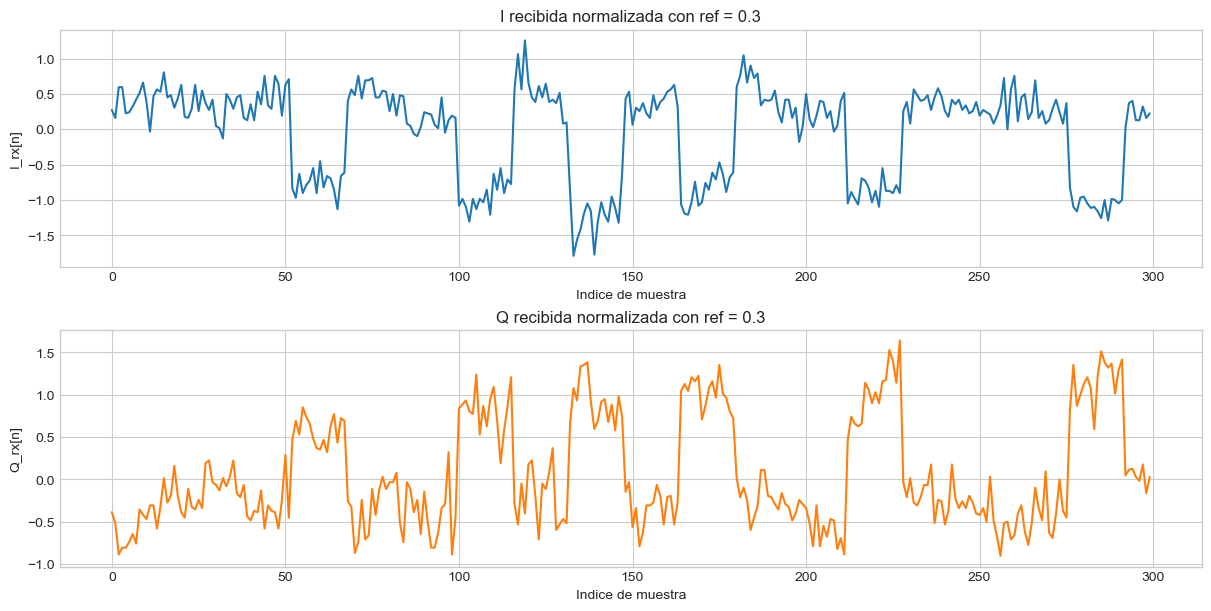

In [130]:
rxPower_ref03 = np.mean(np.abs(rxSignal_ref03)**2)
rxSignalNorm_ref03 = rxSignal_ref03 / np.sqrt(rxPower_ref03)

rx_I_ref03 = np.real(rxSignalNorm_ref03)
rx_Q_ref03 = np.imag(rxSignalNorm_ref03)

print("Potencia antes de normalizar:", rxPower_ref03)
print("Potencia despues de normalizar:", np.mean(np.abs(rxSignalNorm_ref03)**2))

fig, axes = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)
axes[0].plot(n_ref03, rx_I_ref03[:n_preview_ref03])
axes[0].set_title("I recibida normalizada con ref = 0.3")
axes[0].set_xlabel("Indice de muestra")
axes[0].set_ylabel("I_rx[n]")
axes[0].grid(True)

axes[1].plot(n_ref03, rx_Q_ref03[:n_preview_ref03], color="C1")
axes[1].set_title("Q recibida normalizada con ref = 0.3")
axes[1].set_xlabel("Indice de muestra")
axes[1].set_ylabel("Q_rx[n]")
axes[1].grid(True)
plt.show()

## 28. Histogramas recibidos con `ref = 0.3` y comparacion

El objetivo principal del punto 5 es observar como cambia el histograma de la senal recibida cuando las hipotesis dejan de ser equiprobables.

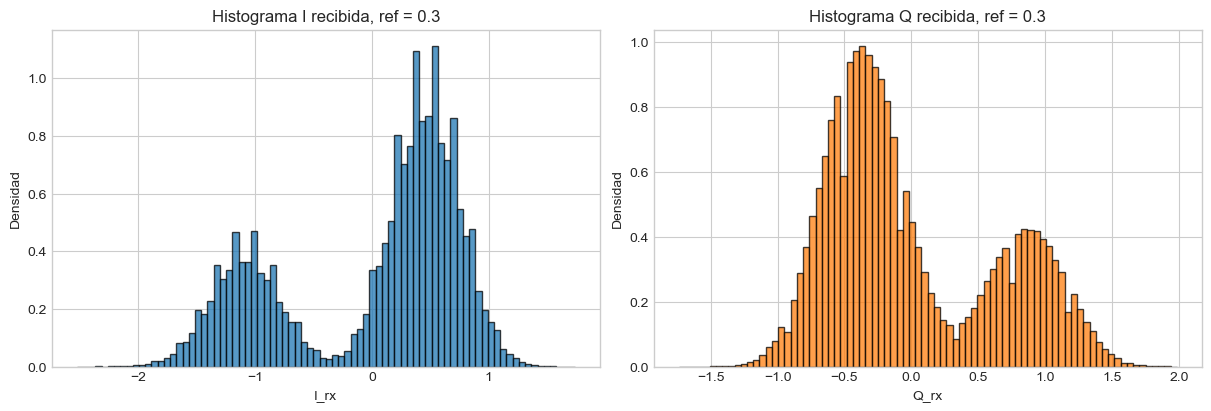

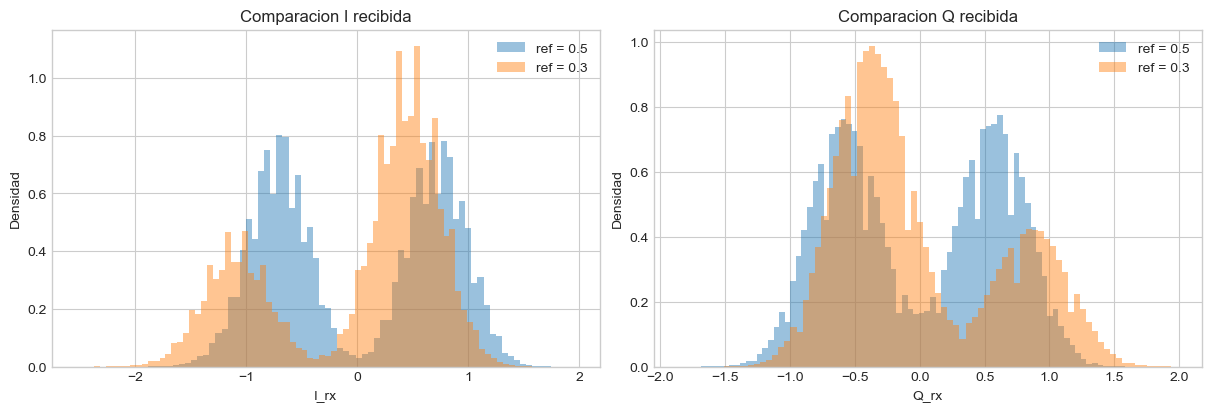

Media I recibida con ref = 0.3: -0.0011741541126117977
Media Q recibida con ref = 0.3: -0.0007789411345462626
Varianza I recibida con ref = 0.3: 0.5958036965721927
Varianza Q recibida con ref = 0.3: 0.4041943180406359


In [131]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].hist(rx_I_ref03, bins=80, density=True, alpha=0.75, edgecolor="black")
axes[0].set_title("Histograma I recibida, ref = 0.3")
axes[0].set_xlabel("I_rx")
axes[0].set_ylabel("Densidad")
axes[0].grid(True)

axes[1].hist(rx_Q_ref03, bins=80, density=True, alpha=0.75, edgecolor="black", color="C1")
axes[1].set_title("Histograma Q recibida, ref = 0.3")
axes[1].set_xlabel("Q_rx")
axes[1].set_ylabel("Densidad")
axes[1].grid(True)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].hist(rxHigh_I, bins=80, density=True, alpha=0.45, label="ref = 0.5")
axes[0].hist(rx_I_ref03, bins=80, density=True, alpha=0.45, label="ref = 0.3")
axes[0].set_title("Comparacion I recibida")
axes[0].set_xlabel("I_rx")
axes[0].set_ylabel("Densidad")
axes[0].legend()
axes[0].grid(True)

axes[1].hist(rxHigh_Q, bins=80, density=True, alpha=0.45, label="ref = 0.5")
axes[1].hist(rx_Q_ref03, bins=80, density=True, alpha=0.45, label="ref = 0.3")
axes[1].set_title("Comparacion Q recibida")
axes[1].set_xlabel("Q_rx")
axes[1].set_ylabel("Densidad")
axes[1].legend()
axes[1].grid(True)
plt.show()

print("Media I recibida con ref = 0.3:", np.mean(rx_I_ref03))
print("Media Q recibida con ref = 0.3:", np.mean(rx_Q_ref03))
print("Varianza I recibida con ref = 0.3:", np.var(rx_I_ref03))
print("Varianza Q recibida con ref = 0.3:", np.var(rx_Q_ref03))

## 29. PSD recibida con `ref = 0.3`

Tambien observamos la distribucion espectral de la senal recibida para mantener la comparacion con los puntos anteriores.

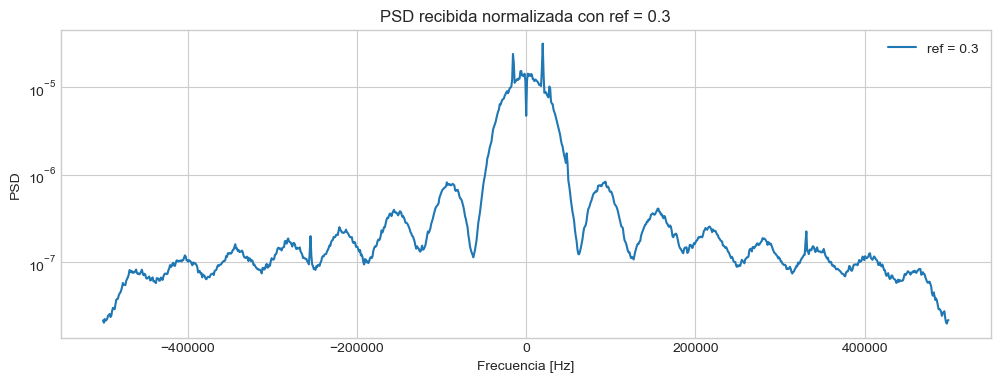

In [132]:
f_rx_ref03, Pxx_rx_ref03 = welch(
    rxSignalNorm_ref03,
    fs=SamplingRate,
    window="hann",
    nperseg=1024,
    return_onesided=False,
    scaling="density",
)

plt.figure(figsize=(12, 4))
plt.semilogy(np.fft.fftshift(f_rx_ref03), np.fft.fftshift(Pxx_rx_ref03), label="ref = 0.3")
plt.title("PSD recibida normalizada con ref = 0.3")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.legend()
plt.grid(True)
plt.show()

## 30. Filtrado rectangular con `ref = 0.3`

Repetimos el filtrado rectangular de 16 muestras para observar la distribucion luego de acumular energia durante una ventana de simbolo.

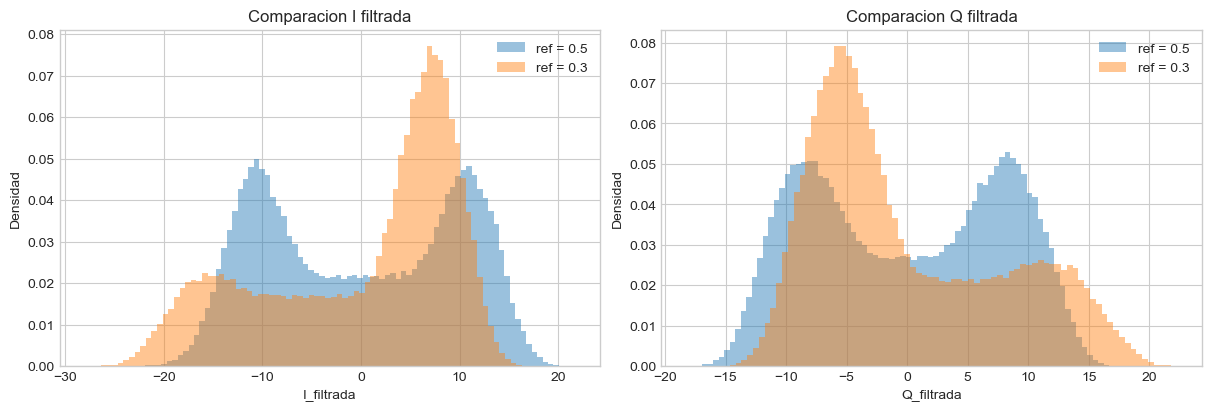

In [133]:
rxSignalFiltered_ref03 = np.convolve(rxSignalNorm_ref03, rect_pulse, mode="same")

rxFiltered_I_ref03 = np.real(rxSignalFiltered_ref03)
rxFiltered_Q_ref03 = np.imag(rxSignalFiltered_ref03)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].hist(rxHighFiltered_I, bins=80, density=True, alpha=0.45, label="ref = 0.5")
axes[0].hist(rxFiltered_I_ref03, bins=80, density=True, alpha=0.45, label="ref = 0.3")
axes[0].set_title("Comparacion I filtrada")
axes[0].set_xlabel("I_filtrada")
axes[0].set_ylabel("Densidad")
axes[0].legend()
axes[0].grid(True)

axes[1].hist(rxHighFiltered_Q, bins=80, density=True, alpha=0.45, label="ref = 0.5")
axes[1].hist(rxFiltered_Q_ref03, bins=80, density=True, alpha=0.45, label="ref = 0.3")
axes[1].set_title("Comparacion Q filtrada")
axes[1].set_xlabel("Q_filtrada")
axes[1].set_ylabel("Densidad")
axes[1].legend()
axes[1].grid(True)
plt.show()

## 31. Conclusion del punto 5

Al configurar `ref = 0.3`, la regla `x = 1 if z > ref else 0` deja de generar hipotesis equiprobables. Como `z` es uniforme entre `0` y `1`, se obtiene aproximadamente `P(x=0)=0.3` y `P(x=1)=0.7`. Despues del mapeo `0 -> -1` y `1 -> +1`, esto significa que deberian aparecer mas muestras positivas que negativas.

La conclusion principal se ve en el histograma: ya no se esperan dos grupos con el mismo peso, como ocurria con `ref = 0.5`, sino una distribucion desbalanceada. El grupo asociado al nivel positivo deberia tener mayor area o mayor cantidad de muestras que el grupo negativo. En la senal recibida, el ruido y el canal ensanchan ambos grupos, pero si la recepcion es suficientemente buena todavia se observa esa asimetria.

Este punto muestra que el histograma recibido no depende solamente del ruido del canal. Tambien refleja la probabilidad de ocurrencia de las hipotesis transmitidas. Por eso cambiar `ref` modifica la distribucion estadistica de la senal aun cuando se mantengan los mismos niveles `-1` y `+1`.

# Punto 6 - Hipotesis multinivel equiprobable

Ahora modificamos la senal transmitida para que la hipotesis pertenezca al conjunto:

```text
H = {-1, -0.3333, +0.3333, +1}
```

con igual probabilidad para cada valor. El objetivo principal de este punto es observar el histograma de la senal recibida por el SDR y describir si aparecen cuatro niveles distinguibles o si el canal/ruido los mezcla.

## 32. Generacion de hipotesis multinivel equiprobable

Elegimos aleatoriamente entre los cuatro niveles con la misma probabilidad. Luego repetimos cada valor `2**4` veces para mantener la misma duracion de simbolo que en los puntos anteriores.

In [134]:
levels = np.array([-1.0, -0.3333, 0.3333, 1.0])

indices_multilevel = rng.integers(0, len(levels), size=nb_samples)
h_multilevel = levels[indices_multilevel]

pulse_train_multilevel = np.repeat(h_multilevel, samples_per_symbol)
txSignal_multilevel = pulse_train_multilevel + 1j * pulse_train_multilevel

print("Niveles posibles:", levels)
print("Primeras 20 hipotesis multinivel:")
print(h_multilevel[:20])
print("Longitud de h_multilevel:", len(h_multilevel))
print("Longitud de txSignal_multilevel:", len(txSignal_multilevel))

for level in levels:
    print(f"Fraccion de nivel {level}:", np.mean(h_multilevel == level))

Niveles posibles: [-1.     -0.3333  0.3333  1.    ]
Primeras 20 hipotesis multinivel:
[-0.3333 -1.     -0.3333  0.3333  0.3333 -1.     -1.      0.3333  0.3333
 -0.3333 -1.     -1.      1.      1.     -1.      0.3333  0.3333 -1.
 -0.3333  1.    ]
Longitud de h_multilevel: 16384
Longitud de txSignal_multilevel: 262144
Fraccion de nivel -1.0: 0.25054931640625
Fraccion de nivel -0.3333: 0.25439453125
Fraccion de nivel 0.3333: 0.24560546875
Fraccion de nivel 1.0: 0.24945068359375


## 33. Analisis local de la senal multinivel

Antes de transmitir, verificamos que el histograma de la senal generada tenga cuatro niveles con pesos aproximadamente iguales.

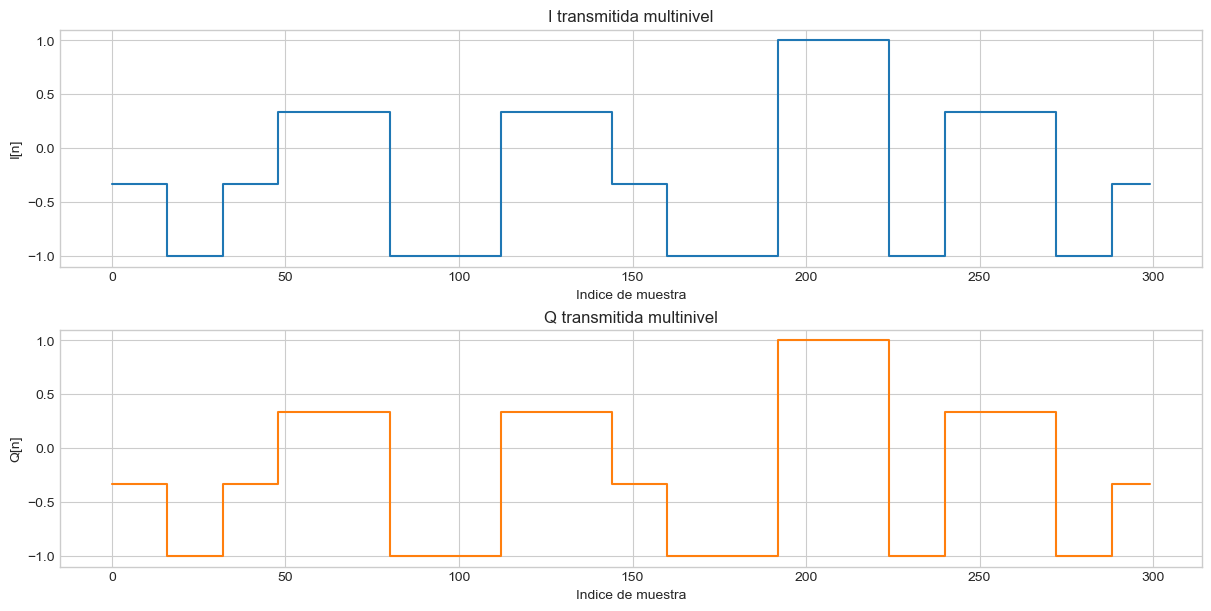

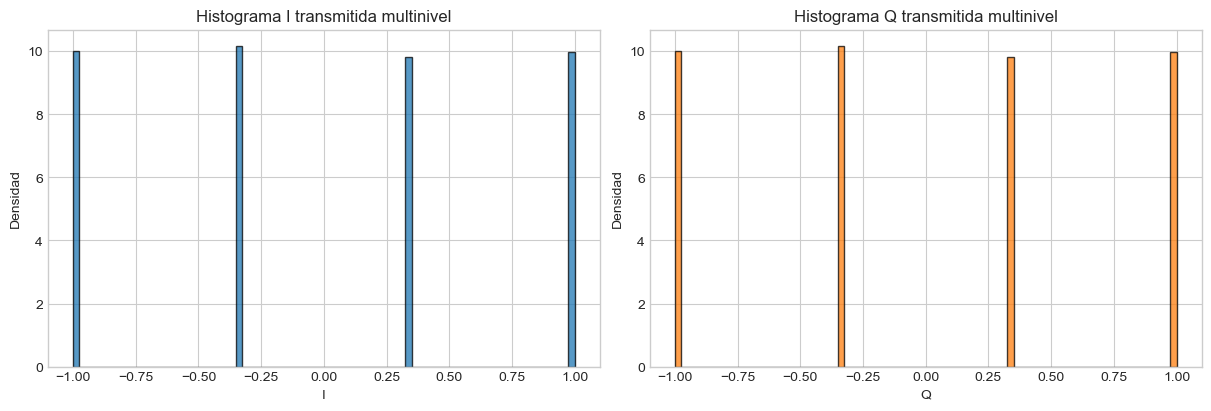

In [135]:
txMulti_I = np.real(txSignal_multilevel)
txMulti_Q = np.imag(txSignal_multilevel)

n_preview_multi = 300
n_multi = np.arange(n_preview_multi)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)
axes[0].step(n_multi, txMulti_I[:n_preview_multi], where="post")
axes[0].set_title("I transmitida multinivel")
axes[0].set_xlabel("Indice de muestra")
axes[0].set_ylabel("I[n]")
axes[0].grid(True)

axes[1].step(n_multi, txMulti_Q[:n_preview_multi], where="post", color="C1")
axes[1].set_title("Q transmitida multinivel")
axes[1].set_xlabel("Indice de muestra")
axes[1].set_ylabel("Q[n]")
axes[1].grid(True)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].hist(txMulti_I, bins=80, density=True, alpha=0.75, edgecolor="black")
axes[0].set_title("Histograma I transmitida multinivel")
axes[0].set_xlabel("I")
axes[0].set_ylabel("Densidad")
axes[0].grid(True)

axes[1].hist(txMulti_Q, bins=80, density=True, alpha=0.75, edgecolor="black", color="C1")
axes[1].set_title("Histograma Q transmitida multinivel")
axes[1].set_xlabel("Q")
axes[1].set_ylabel("Densidad")
axes[1].grid(True)
plt.show()

## 34. Transmision y recepcion multinivel

Como la senal transmitida cambia, destruimos el buffer de transmision, volvemos a configurar `tx_cyclic_buffer` y ajustamos `rx_buffer_size`. Esto sigue la advertencia de la consigna para evitar errores de configuracion o datos viejos en buffers.

In [136]:
sdr.tx_destroy_buffer()
sdr.tx_cyclic_buffer = tx_cyclic_buffer
sdr.rx_buffer_size = len(txSignal_multilevel)
sdr.tx_hardwaregain_chan0 = TxAtten_high_power

# ---- Transmitter
sdr.tx(txSignal_multilevel * (2**14))

# ---- Clear Rx buffer
for i in range(10):
    raw_data_multilevel = sdr.rx()

# ---- Receiver
rxSignal_multilevel = sdr.rx()

print("TxAtten usado:", sdr.tx_hardwaregain_chan0)
print("RxBufferSize configurado:", sdr.rx_buffer_size)
print("Longitud de txSignal_multilevel:", len(txSignal_multilevel))
print("Longitud de rxSignal_multilevel:", len(rxSignal_multilevel))
print("Primeras 10 muestras recibidas:")
print(rxSignal_multilevel[:10])

TxAtten usado: -70
RxBufferSize configurado: 262144
Longitud de txSignal_multilevel: 262144
Longitud de rxSignal_multilevel: 262144
Primeras 10 muestras recibidas:
[ 61.-59.j -32.+41.j -49.+24.j -25.+17.j -47.+11.j -29.+15.j -34.+41.j
 -52.+18.j -50.+19.j -36.+38.j]


## 35. Normalizacion de la senal multinivel recibida

Normalizamos la potencia promedio a 1 para analizar la forma de los histogramas sin depender de la escala absoluta recibida.

In [137]:
rxPower_multilevel = np.mean(np.abs(rxSignal_multilevel)**2)
rxSignalMultilevelNorm = rxSignal_multilevel / np.sqrt(rxPower_multilevel)

rxMulti_I = np.real(rxSignalMultilevelNorm)
rxMulti_Q = np.imag(rxSignalMultilevelNorm)

print("Potencia antes de normalizar:", rxPower_multilevel)
print("Potencia despues de normalizar:", np.mean(np.abs(rxSignalMultilevelNorm)**2))

Potencia antes de normalizar: 2616.4945678710938
Potencia despues de normalizar: 1.0


## 36. Grafica temporal e histograma de la senal multinivel recibida

La consigna pide mostrar el histograma de la senal recibida. Tambien graficamos una porcion temporal para tener contexto visual.

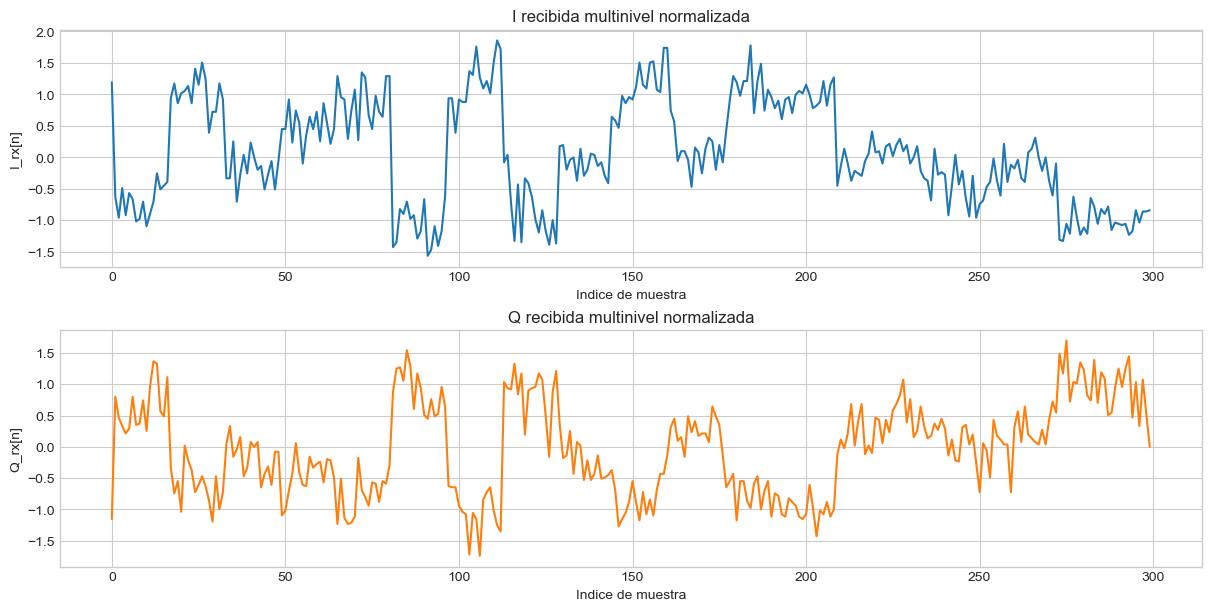

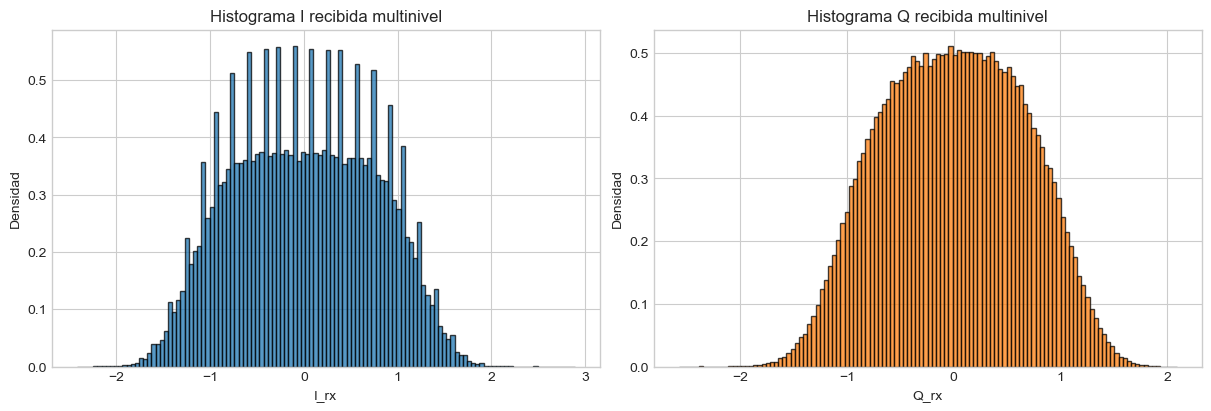

Media I recibida multinivel: 0.004734319913044653
Media Q recibida multinivel: 0.0009061752164107805
Varianza I recibida multinivel: 0.5599484592751721
Varianza Q recibida multinivel: 0.44002830578626606


In [138]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)
axes[0].plot(n_multi, rxMulti_I[:n_preview_multi])
axes[0].set_title("I recibida multinivel normalizada")
axes[0].set_xlabel("Indice de muestra")
axes[0].set_ylabel("I_rx[n]")
axes[0].grid(True)

axes[1].plot(n_multi, rxMulti_Q[:n_preview_multi], color="C1")
axes[1].set_title("Q recibida multinivel normalizada")
axes[1].set_xlabel("Indice de muestra")
axes[1].set_ylabel("Q_rx[n]")
axes[1].grid(True)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].hist(rxMulti_I, bins=120, density=True, alpha=0.75, edgecolor="black")
axes[0].set_title("Histograma I recibida multinivel")
axes[0].set_xlabel("I_rx")
axes[0].set_ylabel("Densidad")
axes[0].grid(True)

axes[1].hist(rxMulti_Q, bins=120, density=True, alpha=0.75, edgecolor="black", color="C1")
axes[1].set_title("Histograma Q recibida multinivel")
axes[1].set_xlabel("Q_rx")
axes[1].set_ylabel("Densidad")
axes[1].grid(True)
plt.show()

print("Media I recibida multinivel:", np.mean(rxMulti_I))
print("Media Q recibida multinivel:", np.mean(rxMulti_Q))
print("Varianza I recibida multinivel:", np.var(rxMulti_I))
print("Varianza Q recibida multinivel:", np.var(rxMulti_Q))

## 37. Conclusion del punto 6

En este punto la senal deja de ser binaria y pasa a tener cuatro niveles posibles: `-1`, `-0.3333`, `+0.3333` y `+1`, todos con igual probabilidad. En un caso ideal, el histograma transmitido deberia mostrar cuatro concentraciones con areas similares, una por cada hipotesis.

Al recibir la senal con el SDR, cada nivel aparece ensanchado por ruido, filtrado, desajustes de ganancia/fase y efectos propios del canal inalambrico. Si la relacion senal-ruido es buena, el histograma recibido deberia mostrar cuatro regiones distinguibles. Si el ruido es alto, los niveles intermedios `-0.3333` y `+0.3333` son los mas dificiles de separar porque estan mas cerca entre si que los niveles extremos.

La conclusion de comunicaciones digitales es que aumentar la cantidad de niveles permite representar mas informacion por simbolo, pero reduce la distancia entre hipotesis vecinas. Al reducirse esa distancia, el sistema se vuelve mas sensible al ruido y aumenta la probabilidad de error si no se mejora la potencia, el filtrado, la sincronizacion o la calidad del canal.